# Asthma incidence analysis (asthma_incidence.ipynb)

**Purpose:** Calculate borough-level asthma incidence rates by merging SPARCS hospitalizations with ACS population data, then explore relationships with NYCCAS air pollution indicators.

**Data sources:**
- data_csv/SPARCS_by_borough_2010-2024.csv
- data_csv/ACS_socioeconomic_indicators_2010-2024_Data.csv
- data_csv/NYCCAS-Yearly-Borough.csv

**Dependencies:** pandas, matplotlib, seaborn

**How to run:** Activate your project environment and run cells in order. Ensure the ACS CSV exists before merging.


In [1]:
# Consolidated imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load data
sparcs = pd.read_csv("data_csv/SPARCS_by_borough_2010-2024.csv")
acs = pd.read_csv("data_csv/ACS_socioeconomic_indicators_2010-2024_Data.csv")

# Standardize join keys — lowercase for safe merging
sparcs['Borough'] = sparcs['Borough'].str.strip().str.title()
acs['borough'] = acs['borough'].str.strip().str.title()

# Merge on Year + Borough
merged_asthma = sparcs.merge(
    acs[['year', 'borough', 'total_population']],
    left_on=['Year', 'Borough'],
    right_on=['year', 'borough'],
    how='left'
)

# Calculate asthma incidence rate per 100k
merged_asthma['asthma_incidence_rate'] = (
    merged_asthma['Asthma_Cases'] / merged_asthma['total_population']
) * 100_000

# Drop redundant columns from merge
merged_asthma = merged_asthma.drop(columns=['year', 'borough'])

merged_asthma = merged_asthma[['Year', 'Borough', 'Asthma_Cases', 'total_population', 'asthma_incidence_rate']]

merged_asthma.to_csv("data_csv/merged_asthma_data.csv", index=False)

In [3]:
# Shared color map for borough-level plots
color_map = {
    'Bronx': 'tomato',
    'Brooklyn': 'steelblue',
    'Manhattan': 'green',
    'Queens': 'purple',
    'Staten Island': 'orange'
}

In [4]:
# Load data
asthma = merged_asthma.copy()
nyccas = pd.read_csv("data_csv/NYCCAS-Yearly-Borough.csv")

# Standardize join keys
asthma['Borough'] = asthma['Borough'].str.strip().str.title()
nyccas['Borough'] = nyccas['Borough'].str.strip().str.title()
nyccas.rename(columns={'year': 'Year'}, inplace=True)

# Merge
merged_full = asthma.merge(nyccas, on=['Year', 'Borough'], how='inner')
print(f"Merged shape: {merged_full.shape}")
print(merged_full.head())

Merged shape: (23, 6)
   Year    Borough  Asthma_Cases  total_population  asthma_incidence_rate  \
0  2019      Bronx          5164         1418207.0             364.121740   
1  2019  Manhattan          1562         1628706.0              95.904356   
2  2019     Queens          2203         2253858.0              97.743514   
3  2020      Bronx          2772               NaN                    NaN   
4  2020   Brooklyn          1730               NaN                    NaN   

       Value  
0  16.358190  
1  12.800775  
2   7.360308  
3  10.284048  
4   9.552288  


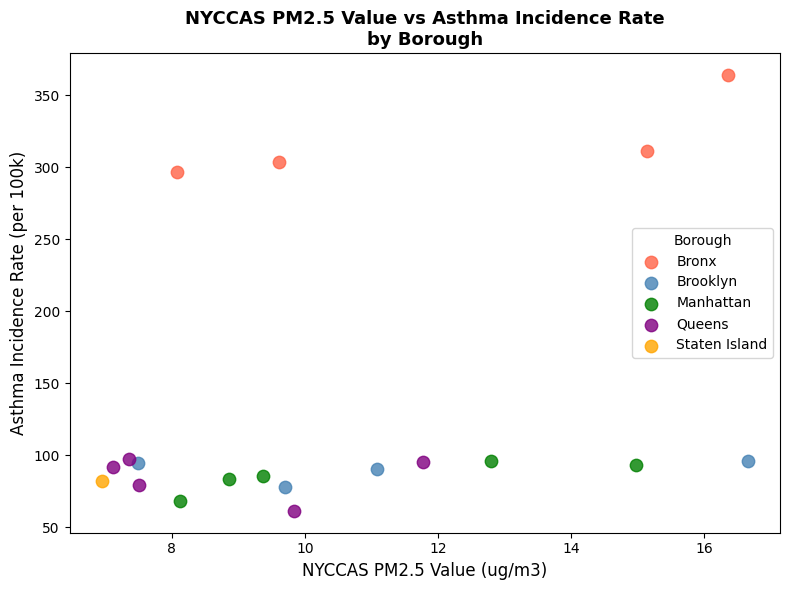

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))

for borough, group in merged_full.groupby('Borough'):
    ax.scatter(group['Value'], group['asthma_incidence_rate'],
               label=borough, color=color_map.get(borough, 'gray'),
               s=80, alpha=0.8)

ax.set_xlabel('NYCCAS PM2.5 Value (ug/m3)', fontsize=12)
ax.set_ylabel('Asthma Incidence Rate (per 100k)', fontsize=12)
ax.set_title('NYCCAS PM2.5 Value vs Asthma Incidence Rate\nby Borough', fontsize=13, fontweight='bold')
ax.legend(title='Borough')
plt.tight_layout()
plt.show()

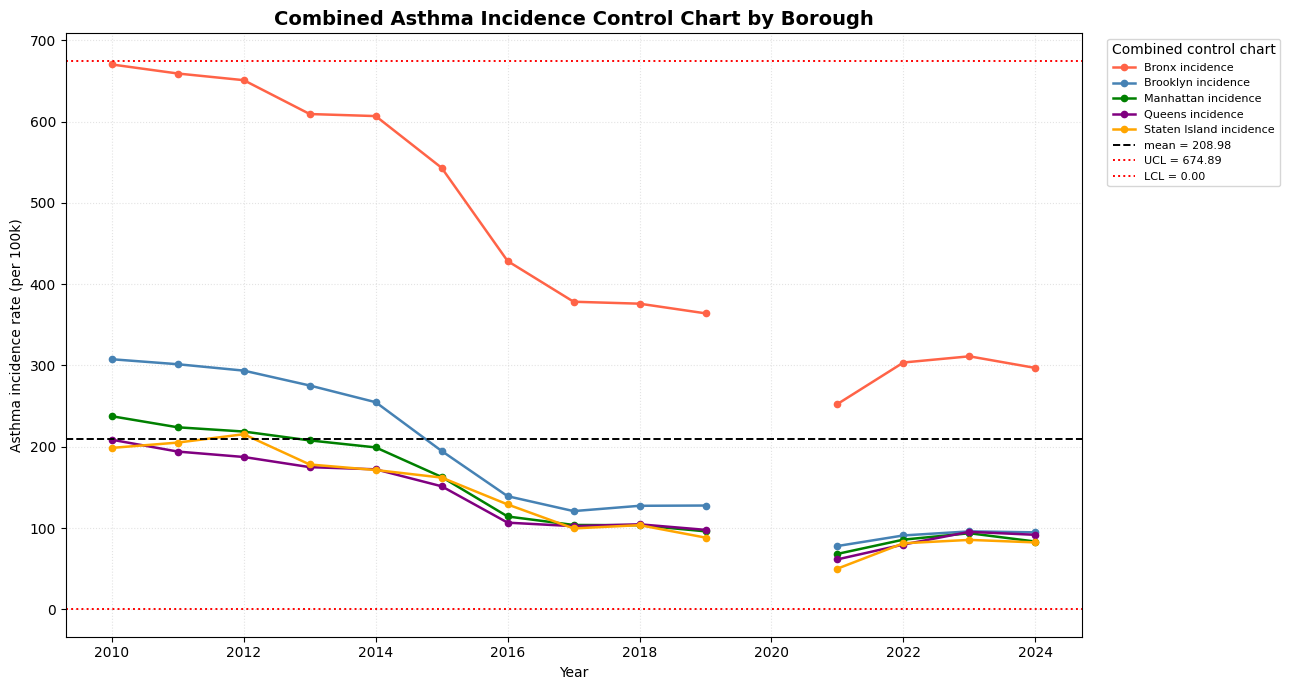

In [6]:
m_borough = merged_asthma[["Year", "Borough", "asthma_incidence_rate"]].copy()
boroughs = sorted(m_borough["Borough"].unique())

combined_mean = m_borough["asthma_incidence_rate"].mean()
combined_std = m_borough["asthma_incidence_rate"].std(ddof=1)
combined_ucl = combined_mean + 3 * combined_std
combined_lcl = max(combined_mean - 3 * combined_std, 0)

fig, ax = plt.subplots(figsize=(13, 7))

for borough in boroughs:
    b_data = m_borough[m_borough["Borough"] == borough].sort_values("Year")
    line_color = color_map[borough]

    ax.plot(
        b_data["Year"],
        b_data["asthma_incidence_rate"],
        "-o",
        color=line_color,
        linewidth=1.8,
        markersize=4.5,
        label=f"{borough} incidence"
    )

    out_of_control = (b_data["asthma_incidence_rate"] > combined_ucl) | (b_data["asthma_incidence_rate"] < combined_lcl)
    if out_of_control.any():
        ax.scatter(
            b_data.loc[out_of_control, "Year"],
            b_data.loc[out_of_control, "asthma_incidence_rate"],
            color="crimson",
            edgecolor="black",
            s=65,
            zorder=5
        )

ax.axhline(combined_mean, linestyle="--", color="black", linewidth=1.4, label=f"mean = {combined_mean:.2f}")
ax.axhline(combined_ucl, linestyle=":", color="red", linewidth=1.4, label=f"UCL = {combined_ucl:.2f}")
ax.axhline(combined_lcl, linestyle=":", color="red", linewidth=1.4, label=f"LCL = {combined_lcl:.2f}")

ax.set_title("Combined Asthma Incidence Control Chart by Borough", fontsize=14, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Asthma incidence rate (per 100k)")
ax.grid(True, linestyle=":", alpha=0.35)
ax.legend(title="Combined control chart", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

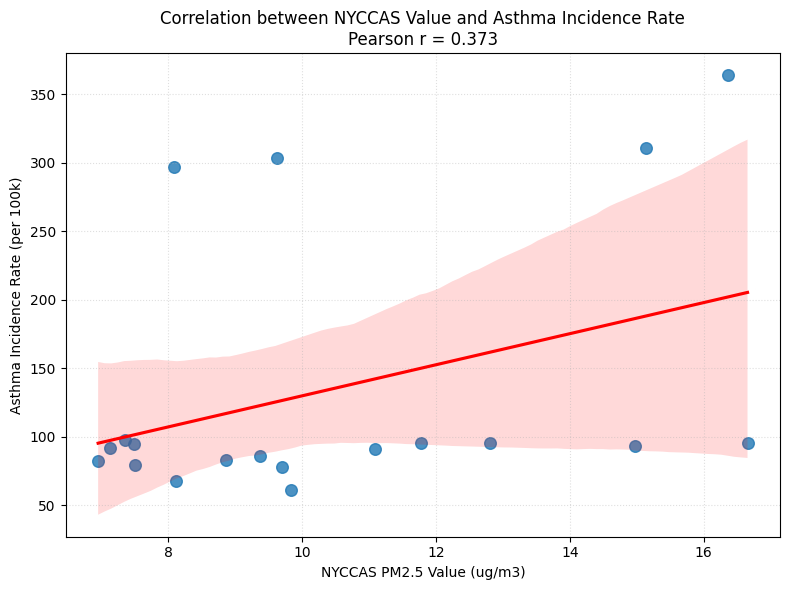

In [7]:
plot_df = merged_full[["Value", "asthma_incidence_rate", "Borough"]].dropna()

corr = plot_df["Value"].corr(plot_df["asthma_incidence_rate"])

plt.figure(figsize=(8, 6))
sns.regplot(
    data=plot_df,
    x="Value",
    y="asthma_incidence_rate",
    scatter_kws={"alpha": 0.8, "s": 70},
    line_kws={"color": "red"}
)

plt.title(f"Correlation between NYCCAS Value and Asthma Incidence Rate\nPearson r = {corr:.3f}")
plt.xlabel("NYCCAS PM2.5 Value (ug/m3)")
plt.ylabel("Asthma Incidence Rate (per 100k)")
plt.grid(True, linestyle=":", alpha=0.4)
plt.tight_layout()
plt.show()